In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
low_path = "LOL-v2/train/low"
high_path = "LOL-v2/Train/high"

In [3]:
image_name = os.listdir(low_path)[24]

image_name

'img1261.png'

In [4]:
low_img = cv2.imread(os.path.join(low_path, image_name))
high_img = cv2.imread(os.path.join(high_path, image_name))

low_img = cv2.cvtColor(low_img, cv2.COLOR_BGR2RGB)
high_img = cv2.cvtColor(high_img, cv2.COLOR_BGR2RGB)

In [5]:
def show_images(images, titles, figsize=(18,6)):

    plt.figure(figsize=figsize)

    for i in range(len(images)):

        plt.subplot(1, len(images), i+1)

        if len(images[i].shape) == 2:
            plt.imshow(images[i], cmap='gray')
        else:
            plt.imshow(images[i])

        plt.title(titles[i])
        plt.axis("off")

    plt.show()

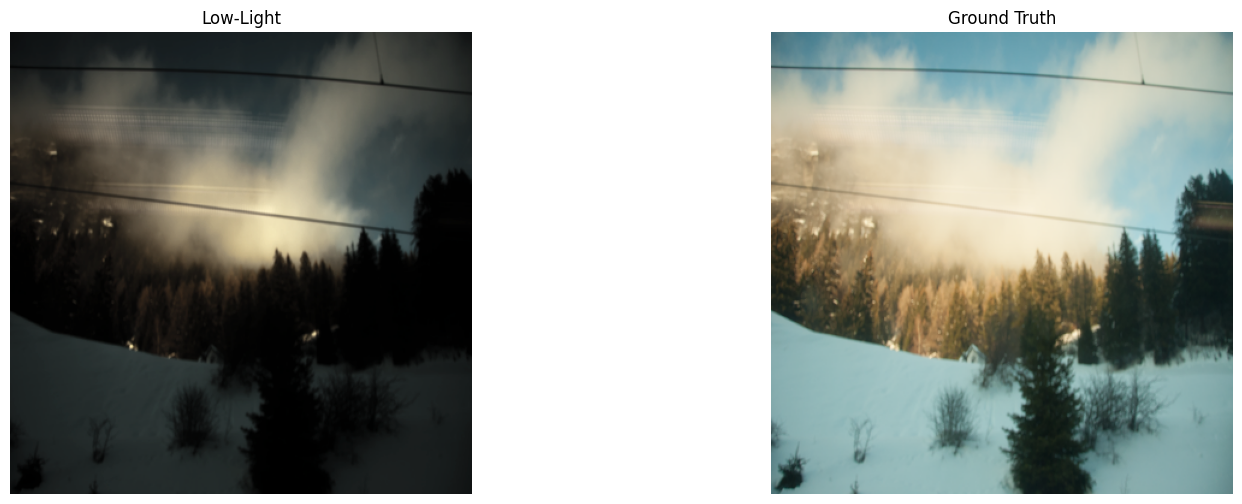

In [6]:
show_images(
    [low_img, high_img],
    ["Low-Light", "Ground Truth"]
)

In [7]:
# histogram-equilizer

In [8]:
gray_low = cv2.cvtColor(low_img, cv2.COLOR_RGB2GRAY)

In [9]:
gray_high = cv2.cvtColor(high_img, cv2.COLOR_RGB2GRAY)

In [10]:
hist_eq = cv2.equalizeHist(gray_low)

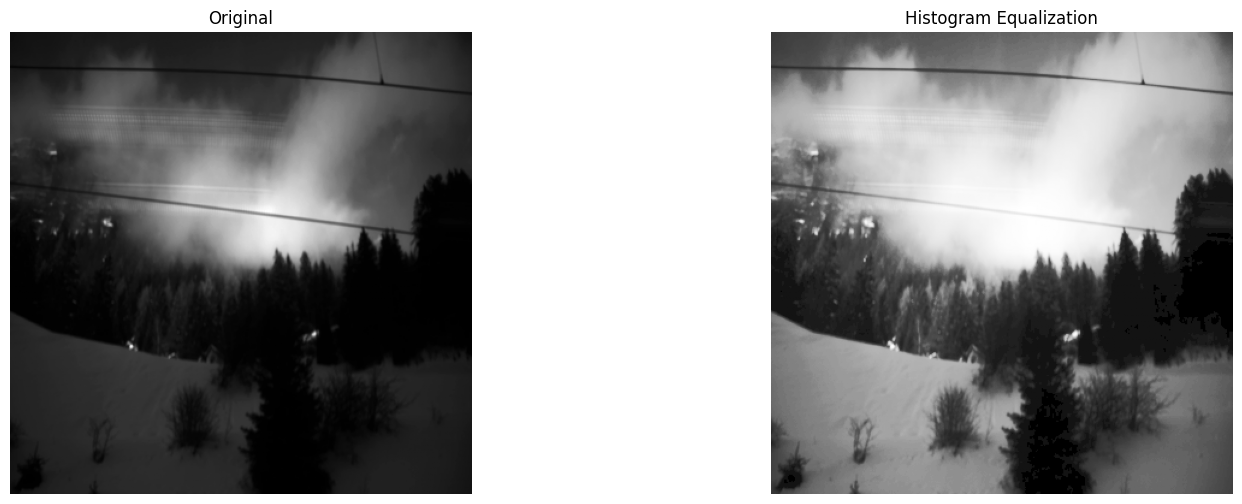

In [11]:
show_images(
    [gray_low, hist_eq],
    ["Original", "Histogram Equalization"]
)

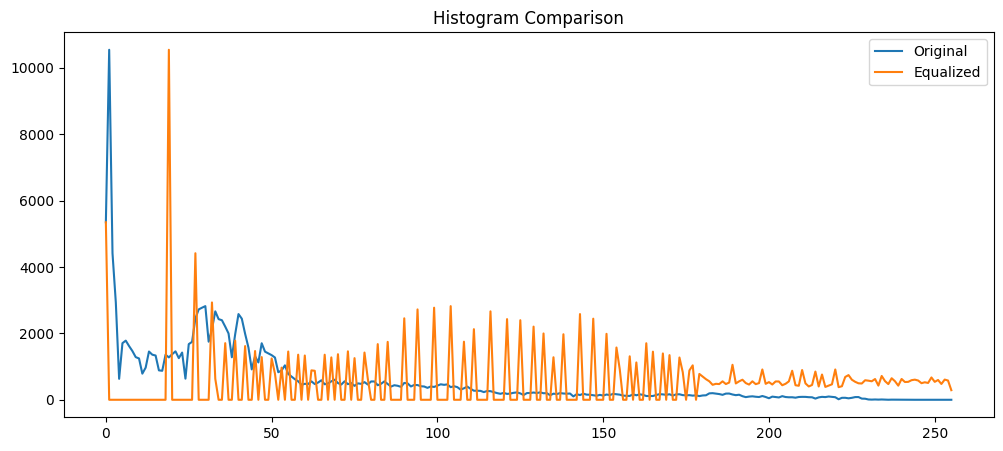

In [12]:
hist_original = cv2.calcHist(
    [gray_low],
    [0],
    None,
    [256],
    [0,256]
)

hist_eq_hist = cv2.calcHist(
    [hist_eq],
    [0],
    None,
    [256],
    [0,256]
)

plt.figure(figsize=(12,5))

plt.plot(hist_original, label="Original")
plt.plot(hist_eq_hist, label="Equalized")

plt.legend()
plt.title("Histogram Comparison")

plt.show()

In [ ]:
# clahe

# Contrast Limited Adaptive Histogram Equalization.

In [14]:
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)

In [15]:
clahe_img = clahe.apply(gray_low)

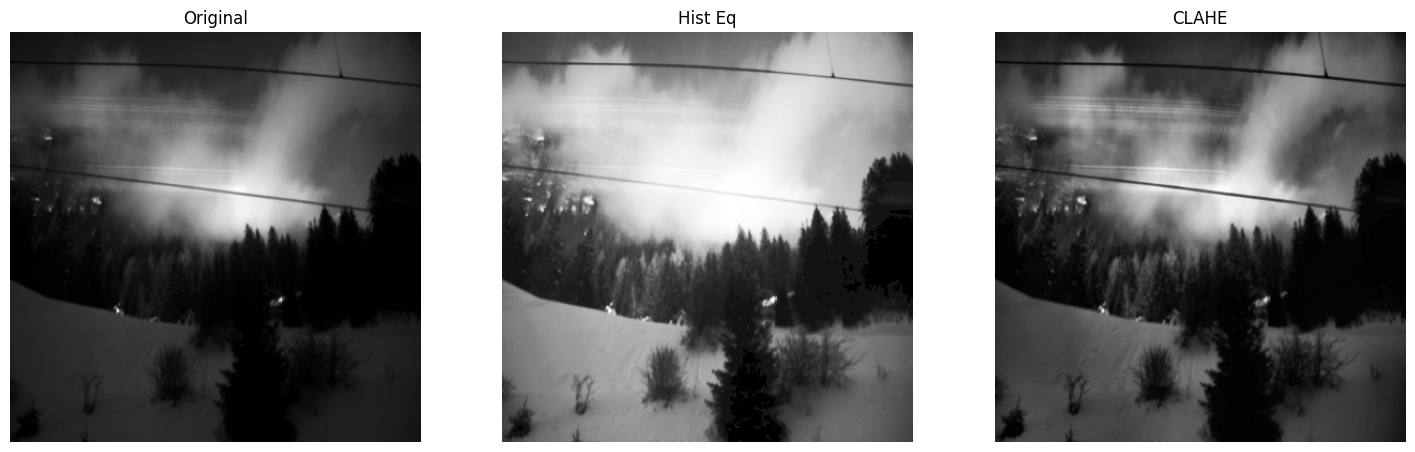

In [16]:
show_images(
    [gray_low, hist_eq, clahe_img],
    ["Original", "Hist Eq", "CLAHE"]
)

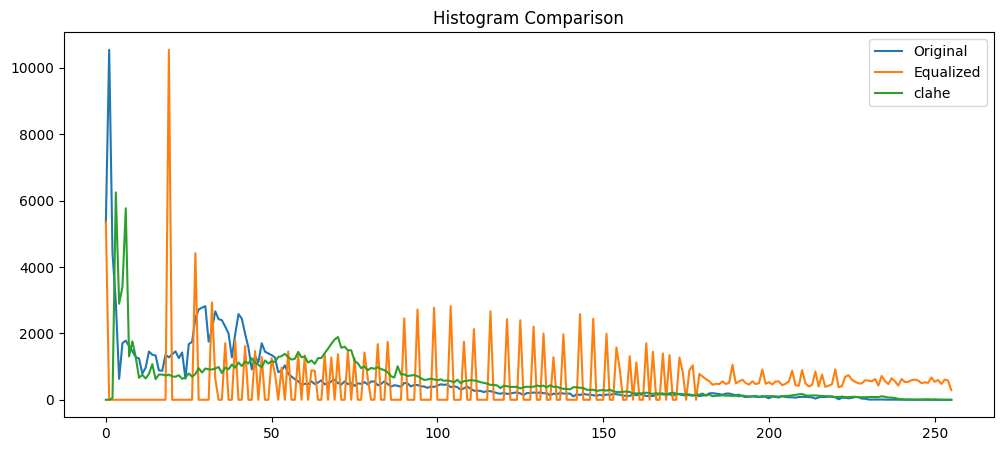

In [17]:
hist_original = cv2.calcHist(
    [gray_low],
    [0],
    None,
    [256],
    [0,256]
)

hist_eq_hist = cv2.calcHist(
    [hist_eq],
    [0],
    None,
    [256],
    [0,256]
)

hist_clahe = cv2.calcHist(
    [clahe_img],
    [0],
    None,
    [256],
    [0,256]
)


plt.figure(figsize=(12,5))

plt.plot(hist_original, label="Original")
plt.plot(hist_eq_hist, label="Equalized")
plt.plot(hist_clahe ,label="clahe")

plt.legend()
plt.title("Histogram Comparison")

plt.show()

In [18]:
# gamma correction

In [19]:
# (I_out) = (I_in)^(y)

# y < 1 ==> brighten
# y > 1 ==> darken

In [20]:
# (0 - 255) -> (0 - 1)

In [21]:
normalized = low_img / 255.0

In [22]:
gamma = 0.5

In [23]:
gamma_corrected = np.power(normalized, gamma)

In [24]:
gamma_corrected = (gamma_corrected * 255).astype(np.uint8)

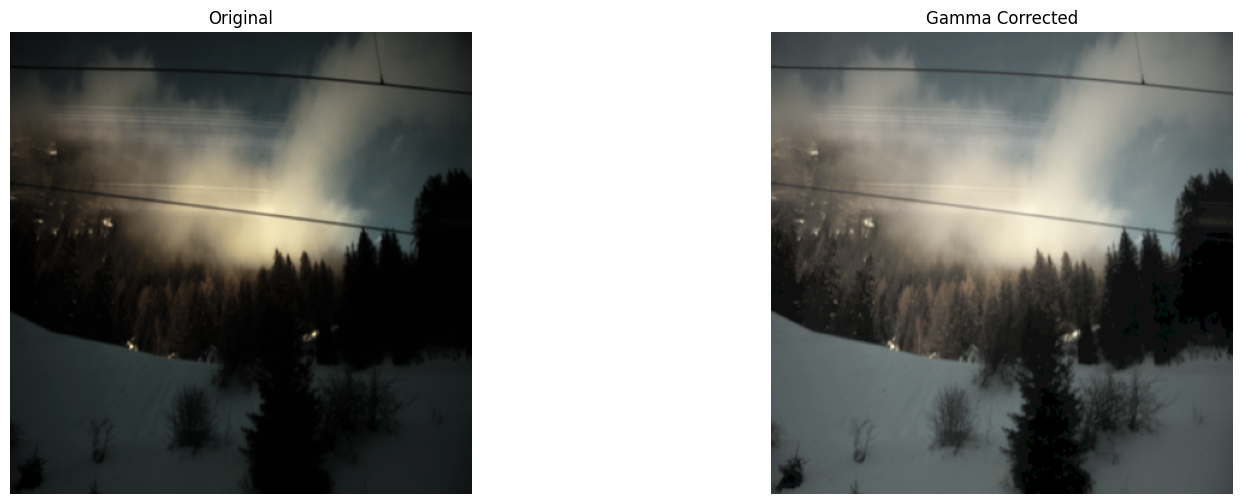

In [25]:
show_images(
    [low_img, gamma_corrected],
    ["Original", "Gamma Corrected"]
)

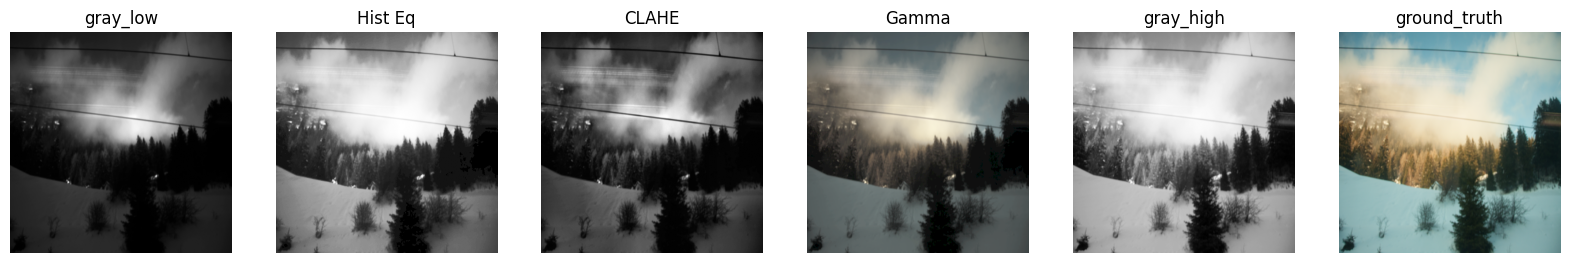

In [26]:
show_images(

    [
        gray_low,
        hist_eq,
        clahe_img,
        gamma_corrected,
        gray_high,
        high_img
    ],

    [
        "gray_low",
        "Hist Eq",
        "CLAHE",
        "Gamma",
        "gray_high",
        "ground_truth"
    ],

    figsize=(20,6)
)

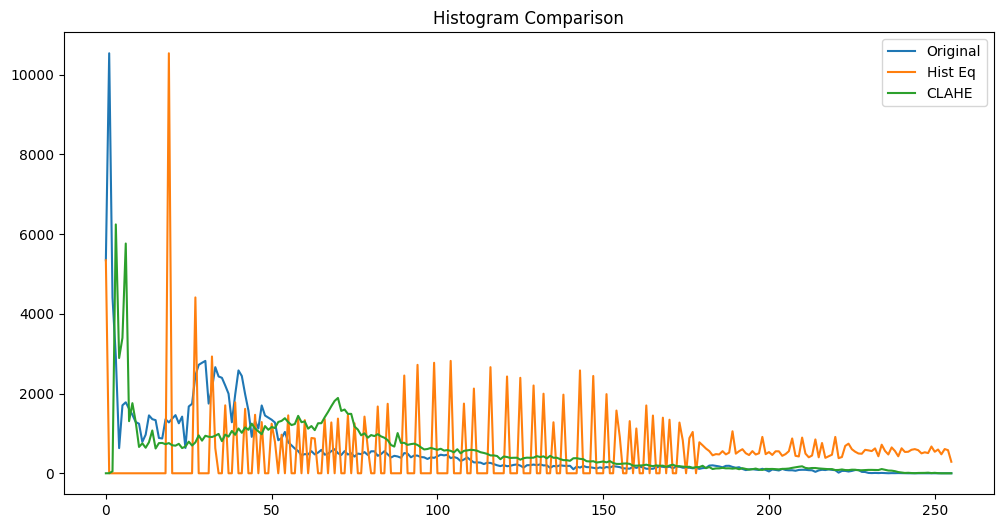

In [27]:
methods = {

    "Original": gray_low,
    "Hist Eq": hist_eq,
    "CLAHE": clahe_img
}

plt.figure(figsize=(12,6))

for name, img in methods.items():

    hist = cv2.calcHist(
        [img],
        [0],
        None,
        [256],
        [0,256]
    )

    plt.plot(hist, label=name)

plt.legend()
plt.title("Histogram Comparison")

plt.show()

In [28]:
def mean_brightness(img):

    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    return np.mean(img)

In [29]:
results = {

    "Original": mean_brightness(gray_low),
    "Hist Eq": mean_brightness(hist_eq),
    "CLAHE": mean_brightness(clahe_img),
    "Gamma": mean_brightness(gamma_corrected),
    "Ground Truth": mean_brightness(high_img)
}

results

{'Original': np.float64(48.93237982855903),
 'Hist Eq': np.float64(124.68159315321181),
 'CLAHE': np.float64(68.70490858289931),
 'Gamma': np.float64(96.21902804904514),
 'Ground Truth': np.float64(150.28805881076389)}

In [30]:
def contrast(img):

    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    return np.std(img)

In [31]:
contrast_results = {

    "Original": contrast(gray_low),
    "Hist Eq": contrast(hist_eq),
    "CLAHE": contrast(clahe_img),
    "Gamma": contrast(gamma_corrected),
    "Ground Truth": contrast(high_img)
}

contrast_results

{'Original': np.float64(48.60924865319664),
 'Hist Eq': np.float64(74.79594036471605),
 'CLAHE': np.float64(52.28878194643926),
 'Gamma': np.float64(55.57432972341836),
 'Ground Truth': np.float64(60.95307829353943)}

In [32]:
comparison = pd.DataFrame({

    "Method": list(results.keys()),

    "Brightness": list(results.values()),

    "Contrast": list(contrast_results.values())

})

comparison

,Method,Brightness,Contrast
0,Original,48.932380,48.609249
1,Hist Eq,124.681593,74.795940
2,CLAHE,68.704909,52.288782
3,Gamma,96.219028,55.574330
4,Ground Truth,150.288059,60.953078


In [33]:
high_img.shape

(384, 384, 3)

In [34]:
gray_high

array([[ 94,  95,  97, ..., 116, 116, 116],
       [ 94,  95,  96, ..., 117, 117, 117],
       [ 95,  96,  97, ..., 119, 120, 120],
       ...,
       [108, 105, 100, ..., 125, 123, 122],
       [108, 105, 105, ..., 124, 122, 122],
       [108, 104, 106, ..., 123, 122, 120]], shape=(384, 384), dtype=uint8)